In [43]:
# Importing packages
import numpy as np
import matplotlib.pyplot as plt 
import os

# Setting up a plotting directory in the repository
plot_dir = os.path.join("..", "plots", "eda")
os.makedirs(plot_dir, exist_ok=True)

In [44]:
""" Global parameters """

# Answer to the universe 
np.random.seed(42)

# Number of time periods
T = 1000

In [45]:
""" Autoregreesive Hidden Markov Model with k states AR(k) """

# Defining the function named ark; short of AR(k)
def ark(T, k, rho, sigma, P):

    # Asserting that the inputs are coherent with k states
    assert len(rho) == k, f"rho must be of length {k}"
    assert len(sigma) == k, f"sigma must be of length {k}"
    assert P.shape == (k, k), f"P must be a matrix {k}x{k}"
    assert np.allclose(P.sum(axis=1), 1), "P matrix rows must sum to 1.0"

    # Initiating states and series value 
    states = np.zeros(T, dtype=int)
    y = np.zeros(T)

    # Setting first state and series value
    states[0] = np.random.choice(k)
    y[0] = np.random.normal()

    # Looping through the T datapoints 
    for t in range(1, T):

        # State at time t is a random choice between k states
        states[t] = np.random.choice(k, p=P[states[t-1]])

        # Saving the state at time t to a variable s
        s = states[t]

        # The time series value y depends on rho of state at time t 
        # times the last time series value plus random noise  
        y[t] = rho[s] * y[t-1] + np.random.normal(scale=sigma[s])

    # Returning the states and the time series values y 
    return states, y

In [46]:
""" Inputting parameters for the AR(k) model """

# Number of states k
k = 4

# Rho and sigma parameters are a random uniform distribution
rho_params = np.random.uniform(-0.8, 0.8, k)
sigma_params = np.random.uniform(0.5, 2.0, k)

# Transition matrix chosen at a random dirichlet given states k
P_matrix = np.random.dirichlet(np.ones(k), size=k)

# Saving the simulated states and time series values given ark
simulated_states, simulated_y = ark(T, k, rho_params, sigma_params, P_matrix)

# Printing some values  
print(f"Rho parameters: {rho_params}")
print(f"Sigma parameters: {sigma_params}\n")
print(f"TIme steps: {T}")
print(f"States: {k}\n")
print(f"First 5 states:\n {simulated_states[:5]}")
print(f"First 5 y values:\n {np.round(simulated_y[:5], 4)}")

Rho parameters: [-0.20073581  0.72114289  0.37119031  0.15785357]
Sigma parameters: [0.73402796 0.73399178 0.58712542 1.79926422]

TIme steps: 1000
States: 4

First 5 states:
 [1 0 3 2 1]
First 5 y values:
 [ 0.2221 -0.6083  1.945   0.6604 -1.0113]


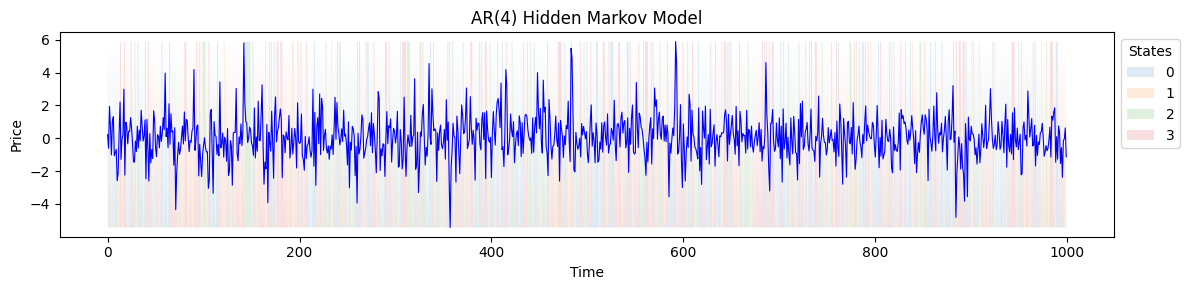

In [47]:
""" Plotting figure """

# Setting figure size
plt.figure(figsize=(12, 3))

# Time index and band limits for fill_between
x = np.arange(T)
lo, hi = simulated_y.min(), simulated_y.max()

# Filling in between the hidden parts
for i in range(k):
    plt.fill_between(
        x, lo, hi,
        where=(simulated_states == i),
        alpha=0.15,
        interpolate=True,
        label=f"{i}",
    )

# Plotting the line segments and filling in gaps
plt.plot(simulated_y, color="blue", linewidth=0.8)

# Adding title, axes titles, and legend
plt.title(f"AR({k}) Hidden Markov Model")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend(title="States", bbox_to_anchor=(1, 1))

# Tight layout
plt.tight_layout()

# Saving and showing the figure
plt.savefig(os.path.join(plot_dir, f"ar{k}-hmm.pdf"), bbox_inches="tight")
plt.show()